In [10]:
import  pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA



In [11]:
df = pd.read_csv(
    filepath_or_buffer='data/Cust_Segmentation.csv'
)

df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


In [12]:
df.shape


(850, 10)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      850 non-null    int64  
 1   Age              850 non-null    int64  
 2   Edu              850 non-null    int64  
 3   Years Employed   850 non-null    int64  
 4   Income           850 non-null    int64  
 5   Card Debt        850 non-null    float64
 6   Other Debt       850 non-null    float64
 7   Defaulted        700 non-null    float64
 8   Address          850 non-null    object 
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 66.5+ KB


In [14]:
df.describe

<bound method NDFrame.describe of      Customer Id  Age  Edu  Years Employed  Income  Card Debt  Other Debt  \
0              1   41    2               6      19      0.124       1.073   
1              2   47    1              26     100      4.582       8.218   
2              3   33    2              10      57      6.111       5.802   
3              4   29    2               4      19      0.681       0.516   
4              5   47    1              31     253      9.308       8.908   
..           ...  ...  ...             ...     ...        ...         ...   
845          846   27    1               5      26      0.548       1.220   
846          847   28    2               7      34      0.359       2.021   
847          848   25    4               0      18      2.802       3.210   
848          849   32    1              12      28      0.116       0.696   
849          850   52    1              16      64      1.866       3.638   

     Defaulted Address  DebtIncomeRatio  

In [15]:
df.drop(
    columns=['Customer Id', 'Address', 'Defaulted'],
    axis=1,
    inplace=True
)

In [16]:
df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio
0,41,2,6,19,0.124,1.073,6.3
1,47,1,26,100,4.582,8.218,12.8
2,33,2,10,57,6.111,5.802,20.9
3,29,2,4,19,0.681,0.516,6.3
4,47,1,31,253,9.308,8.908,7.2


In [17]:
df.shape

(850, 7)

In [19]:
df.dtypes.to_frame(name='dtype')

,dtype
Age,int64
Edu,int64
Years Employed,int64
Income,int64
Card Debt,float64
Other Debt,float64
DebtIncomeRatio,float64


In [20]:
df.isnull().sum()

Age                0
Edu                0
Years Employed     0
Income             0
Card Debt          0
Other Debt         0
DebtIncomeRatio    0
dtype: int64

In [21]:
df.columns

Index(['Age', 'Edu', 'Years Employed', 'Income', 'Card Debt', 'Other Debt',
       'DebtIncomeRatio'],
      dtype='object')

pipeline kurulacak buraya !!!!!!!!


In [24]:
features = ['Age', 'Edu', 'Years Employed', 'Income', 'Card Debt', 'Other Debt',
       'DebtIncomeRatio']
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[features])

X_scaled = pd.DataFrame(X_scaled, columns=features)

X_scaled.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio
0,0.742915,0.312122,-0.378790,-0.718459,-0.683811,-0.590489,-0.576525
1,1.489490,-0.766349,2.573721,1.384325,1.414474,1.512962,0.391387
2,-0.252518,0.312122,0.211712,0.268032,2.134141,0.801704,1.597554
3,-0.750235,0.312122,-0.674041,-0.718459,-0.421643,-0.754467,-0.576525
4,1.489490,-0.766349,3.311849,5.356249,3.638900,1.716094,-0.442507


k=1 || inertia=5950.0
k=2 || inertia=4344.1364794705505
k=3 || inertia=3702.5682009734965
k=4 || inertia=3268.8344912580633
k=5 || inertia=2883.7013376659743
k=6 || inertia=2604.944180598632
k=7 || inertia=2509.5945091794315
k=8 || inertia=2297.9308220802004
k=9 || inertia=2156.895439850018
k=10 || inertia=2067.785845128986


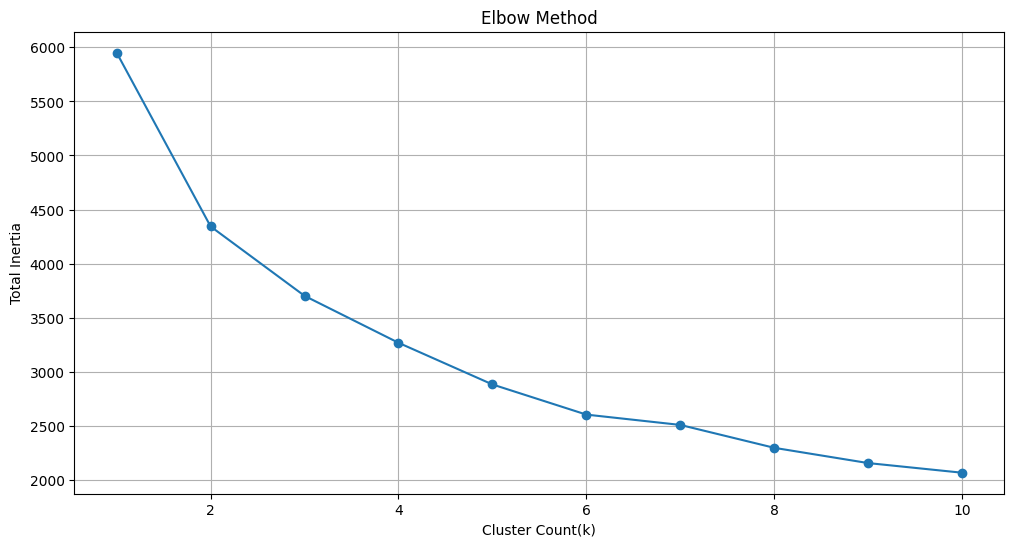

In [33]:
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42
    )
    
    km.fit(X_scaled)

    inertia_values.append(km.inertia_)

    print(f'k={k} || inertia={km.inertia_}')
    
  

plt.figure(figsize=(12,6))
plt.plot(K_range, inertia_values, marker='o')
plt.title('Elbow Method')
plt.xlabel('Cluster Count(k)')
plt.ylabel('Total Inertia')
plt.grid(True)
plt.show()
